# LeRobot MuJoCo Simulation Setup and Usage

This guide explains how to set up the environment, configure the simulation, and run teleoperation-based data collection using the LeRobot framework with MuJoCo (`gym_hil`).

---

## 1. Overview

This project demonstrates a full simulation pipeline for robot learning:

* MuJoCo-based simulation using `gym_hil`
* Keyboard-based teleoperation
* Demonstration data collection in LeRobotDataset format
* Dataset storage for downstream training (e.g., ACT policy)

The simulation task used is:

```
PandaPickCubeKeyboard-v0
```

---

## 2. Environment Setup

### 2.1 Create Python Environment

```bash
conda create -n lerobot_py312 python=3.12 -y
conda activate lerobot_py312
```

### 2.2 Install LeRobot (from source)

```bash
git clone https://github.com/huggingface/lerobot.git
cd lerobot
pip install -e .
```

### 2.3 Install Simulation Dependencies

```bash
pip install -e "[hilserl]"
```

### 2.4 Verify Installation

```bash
python -c "import lerobot; print(lerobot.__version__)"
python -c "import gym_hil; print('gym_hil installed successfully')"
```

---

## 3. Configuration File

Create a JSON configuration file named:

```
env_config_gym_hil_il.json
```

Example configuration:

```json
{
  "env": {
    "name": "gym_hil",
    "task": "PandaPickCubeKeyboard-v0",
    "fps": 10,
    "processor": {
      "control_mode": "keyboard",
      "observation": {
        "add_joint_velocity_to_observation": true,
        "add_ee_pose_to_observation": true,
        "display_cameras": false
      },
      "image_preprocessing": {
        "crop_params_dict": {
          "observation.images.front": [0, 0, 128, 128],
          "observation.images.wrist": [0, 0, 128, 128]
        },
        "resize_size": [128, 128]
      },
      "gripper": {
        "use_gripper": true,
        "gripper_penalty": -0.02
      },
      "reset": {
        "fixed_reset_joint_positions": [0.0, 0.195, 0.0, -2.43, 0.0, 2.62, 0.785],
        "reset_time_s": 2.0,
        "control_time_s": 50.0,
        "terminate_on_success": true
      },
      "reward_classifier": {
        "pretrained_path": null
      }
    }
  },
  "dataset": {
    "repo_id": "your_username/il_gym_pickcube",
    "root": null,
    "task": "PandaPickCubeKeyboard-v0",
    "num_episodes_to_record": 5,
    "replay_episode": null,
    "push_to_hub": false
  },
  "mode": "record",
  "device": "cpu"
}
```

Use this replacement in `lerobot/src/datasets/dataset_writer.py` for _save_episode_data
```python
    def _save_episode_data(self, episode_buffer: dict) -> dict:
        """Save episode data to a parquet file."""
        # Use metadata features as the authoritative schema
        hf_features = get_hf_features_from_features(self._meta.features)
        ep_dict = {key: episode_buffer[key] for key in hf_features}
        
        #--------
        # Normalize scalar-like columns before converting to a Hugging Face dataset.
        # Some values are stored as NumPy arrays with shape (1,), which pass frame validation
        # but fail later because datasets.Value expects scalar-like inputs during encoding.

        def _squeeze_scalar_like_list(values):
            normalized = []
            for v in values:
                if isinstance(v, np.ndarray):
                    arr = np.asarray(v)
                    if arr.shape == (1,):
                        normalized.append(arr[0].item())
                    elif arr.shape == ():
                        normalized.append(arr.item())
                    else:
                        normalized.append(v)
                else:
                    normalized.append(v)
            return normalized

        scalar_like_keys = [
            "next.reward",
            "next.done",
            "complementary_info.discrete_penalty",
        ]

        for key in scalar_like_keys:
            if key in ep_dict:
                ep_dict[key] = _squeeze_scalar_like_list(ep_dict[key])
        #--------
        
        ep_dataset = datasets.Dataset.from_dict(ep_dict, features=hf_features, split="train")
        ep_dataset = embed_images(ep_dataset)
        ep_num_frames = len(ep_dataset)

        if self._latest_episode is None:
            chunk_idx, file_idx = 0, 0
            global_frame_index = 0
            self._current_file_start_frame = 0
            if self._meta.episodes is not None and len(self._meta.episodes) > 0:
                latest_ep = self._meta.episodes[-1]
                global_frame_index = latest_ep["dataset_to_index"]
                chunk_idx = latest_ep["data/chunk_index"]
                file_idx = latest_ep["data/file_index"]

                chunk_idx, file_idx = update_chunk_file_indices(chunk_idx, file_idx, self._meta.chunks_size)
                self._current_file_start_frame = global_frame_index
        else:
            latest_ep = self._latest_episode
            chunk_idx = latest_ep["data/chunk_index"]
            file_idx = latest_ep["data/file_index"]
            global_frame_index = latest_ep["index"][-1] + 1

            latest_path = self._root / self._meta.data_path.format(chunk_index=chunk_idx, file_index=file_idx)
            latest_size_in_mb = get_file_size_in_mb(latest_path)

            frames_in_current_file = global_frame_index - self._current_file_start_frame
            av_size_per_frame = (
                latest_size_in_mb / frames_in_current_file if frames_in_current_file > 0 else 0
            )

            if latest_size_in_mb + av_size_per_frame * ep_num_frames >= self._meta.data_files_size_in_mb:
                chunk_idx, file_idx = update_chunk_file_indices(chunk_idx, file_idx, self._meta.chunks_size)
                self.close_writer()
                self._current_file_start_frame = global_frame_index

        ep_dict["data/chunk_index"] = chunk_idx
        ep_dict["data/file_index"] = file_idx

        path = self._root / self._meta.data_path.format(chunk_index=chunk_idx, file_index=file_idx)
        path.parent.mkdir(parents=True, exist_ok=True)

        table = ep_dataset.with_format("arrow")[:]
        if not self._pq_writer:
            self._pq_writer = pq.ParquetWriter(
                path, schema=table.schema, compression="snappy", use_dictionary=True
            )
        self._pq_writer.write_table(table)

        metadata = {
            "data/chunk_index": chunk_idx,
            "data/file_index": file_idx,
            "dataset_from_index": global_frame_index,
            "dataset_to_index": global_frame_index + ep_num_frames,
        }

        self._latest_episode = {**ep_dict, **metadata}
        self._recorded_frames += ep_num_frames

        return metadata

```
---

## 4. Running the Simulation

Run the simulation from the terminal:

```bash
python -m lerobot.rl.gym_manipulator --config_path env_config_gym_hil_il.json
```

---

## 5. Keyboard Controls

Click on the simulation window before using the keyboard.

Controls:

* Arrow keys: Move in X-Y plane
* Shift / Shift_R: Move along Z axis
* Left Ctrl / Right Ctrl: Open/close gripper
* Space: Start/Stop intervention
* Enter: End episode with SUCCESS
* Backspace: End episode with FAILURE
* ESC: Exit simulation

Important:

* The robot will not move unless intervention is enabled.
* Press `Space` before controlling the robot.

---

## 6. Dataset Output

Recorded datasets are stored locally at:

```
~/.cache/huggingface/lerobot/<username>/<repo_id>
```

The dataset contains:

* Action trajectories
* Robot state information
* Camera images/videos
* Episode metadata

---

## 7. Viewing Recorded Data

### 7.1 Locate video files

```bash
find ~/.cache/huggingface/lerobot/<username>/<repo_id> -name "*.mp4"
```

### 7.2 Play video

```bash
open <video_path>.mp4
```

### 7.3 Load dataset in Python

```python
from lerobot.datasets.lerobot_dataset import LeRobotDataset

dataset = LeRobotDataset("your_username/il_gym_pickcube", video_backend="pyav")
print(dataset)
```

---

## 8. Common Issues

### Simulation ends too quickly

* Check `control_time_s` in config
* Default behavior may limit episode duration

### Keyboard not working

* Ensure simulation window is focused
* Grant macOS Accessibility permissions to Terminal / Python

### Video warnings (AVFFrameReceiver)

* Caused by FFmpeg library conflicts (`cv2` vs `av`)
* Usually safe to ignore unless crashes occur

---

## 9. Next Steps

After collecting demonstrations:

1. Train a policy using:

```bash
lerobot-train --policy.type=act
```

2. Evaluate in simulation
3. Transfer pipeline to real robot (e.g., SO-ARM101)

---

## 10. Summary

This setup enables a full simulation-to-learning pipeline:

* Teleoperation → Dataset → Training → Evaluation

No physical robot is required at this stage.

# This notebook demonstrates how to:
1. Load a MuJoCo simulation environment from gym_hil
2. Inspect the observation and action spaces
3. Run a random policy and save rendered frames as a GIF
4. Document how to record demonstrations into LeRobotDataset format
5. Load a recorded dataset and verify its structure

In [10]:
# This cell tries to initialize the MuJoCo environment and prints observation and action spaces.
# You may need to adapt the import path depending on your local installation and LeRobot version.

import gymnasium as gym

env = gym.make("gym_hil/PandaPickCubeBase-v0")

print("Environment created successfully.")
print("\nObservation space:")
print(env.observation_space)

print("\nAction space:")
print(env.action_space)

Environment created successfully.

Observation space:
Dict('agent_pos': Box(-inf, inf, (18,), float32), 'environment_state': Box(-inf, inf, (3,), float32))

Action space:
Box(-1.0, 1.0, (7,), float32)


In [11]:
# This cell inspects the environment interface, including observation and action spaces.

print("===== Observation Space =====")
print(env.observation_space)

print("\n===== Action Space =====")
print(env.action_space)

# Print additional shape information when available
if hasattr(env.observation_space, "shape"):
    print("\nObservation space shape:", env.observation_space.shape)

if hasattr(env.action_space, "shape"):
    print("Action space shape:", env.action_space.shape)

# Reset once to inspect a real observation sample
obs, info = env.reset()

print("\n===== Observation Type =====")
print(type(obs))

print("\n===== Info Keys =====")
print(info.keys() if hasattr(info, "keys") else info)

# If the observation is a dictionary, inspect each entry
if isinstance(obs, dict):
    print("\n===== Observation Keys =====")
    for key, value in obs.items():
        shape = getattr(value, "shape", None)
        dtype = getattr(value, "dtype", None)
        print(f"{key}: shape={shape}, dtype={dtype}, type={type(value)}")
else:
    print("\nObservation shape:", getattr(obs, "shape", None))
    print("Observation dtype:", getattr(obs, "dtype", None))

===== Observation Space =====
Dict('agent_pos': Box(-inf, inf, (18,), float32), 'environment_state': Box(-inf, inf, (3,), float32))

===== Action Space =====
Box(-1.0, 1.0, (7,), float32)

Observation space shape: None
Action space shape: (7,)

===== Observation Type =====
<class 'dict'>

===== Info Keys =====
dict_keys([])

===== Observation Keys =====
agent_pos: shape=(18,), dtype=float32, type=<class 'numpy.ndarray'>
environment_state: shape=(3,), dtype=float32, type=<class 'numpy.ndarray'>


In [ ]:
# This cell checks the shape and type of one rendered frame.

import numpy as np

debug_env = gym.make("gym_hil/PandaPickCubeBase-v0", render_mode="rgb_array")
obs, info = debug_env.reset()

frame = debug_env.render()

print("Frame type:", type(frame))
print("Frame shape:", np.asarray(frame).shape)
print("Frame dtype:", np.asarray(frame).dtype)

debug_env.close()

Frame type: <class 'list'>
Frame shape: (2, 128, 128, 3)
Frame dtype: uint8


In [ ]:
# This cell creates a rendering-enabled environment, runs a random policy for 100 steps,
# collects frames, handles multi-camera outputs, and saves them as a GIF.

import gymnasium as gym
import imageio.v2 as imageio
import numpy as np

render_task_name = "gym_hil/PandaPickCubeBase-v0"

# Create environment with RGB rendering
render_env = gym.make(render_task_name, render_mode="rgb_array")

frames = []
obs, info = render_env.reset()

for step in range(100):
    action = render_env.action_space.sample()
    obs, reward, terminated, truncated, info = render_env.step(action)

    frame = render_env.render()

    if frame is not None:
        frame = np.asarray(frame)

        # Case 1: multiple camera views (e.g., shape = (2, H, W, C))
        if frame.ndim == 4:
            # Select the first camera view
            frame = frame[0]
            
            # Concatenate two camera views horizontally
            # frame = np.concatenate(frame, axis=1)

        # Ensure correct format (H, W, C)
        if frame.ndim == 3 and frame.shape[-1] == 3:
            frames.append(frame)
        else:
            print(f"Skipped frame with unexpected shape: {frame.shape}")

    if terminated or truncated:
        obs, info = render_env.reset()

render_env.close()

print(f"Collected {len(frames)} valid frames.")

gif_path = "panda_pick_cube_random_policy.gif"

if len(frames) > 0:
    imageio.mimsave(gif_path, frames, fps=10)
    print(f"GIF saved to: {gif_path}")
else:
    print("No valid frames were collected.")

Collected 100 valid frames.
GIF saved to: panda_pick_cube_random_policy.gif


## Teleoperation Instructions

This environment uses keyboard-based teleoperation for the `gym_hil/PandaPickCubeKeyboard-v0` task.

Controls:
- Arrow keys: move the end-effector in the X-Y plane
- Shift / Shift_R: move along the Z axis
- Left Ctrl / Right Ctrl: open or close the gripper
- Space: start or stop intervention
- Enter: end the episode with success
- Backspace: end the episode with failure
- ESC: exit the program

Important notes:
1. Click the simulation window first so it receives keyboard focus.
2. Press `Space` before trying to move the robot.  
   When intervention is off, the robot stays still.
3. After finishing one trial, press `Enter` for a successful episode or `Backspace` for a failed episode.

In [32]:
# This cell prepares and saves a config file for gym_hil teleoperation and data recording.
# The "type" field is removed because it is not a valid field in HILSerlRobotEnvConfig.

import json

record_config = {
    "env": {
        "name": "gym_hil",
        "task": "PandaPickCubeKeyboard-v0",
        "fps": 10,
        "robot": None,
        "teleop": None,
        "processor": {
            "control_mode": "keyboard",
            "observation": {
                "add_joint_velocity_to_observation": True,
                "add_ee_pose_to_observation": True,
                "display_cameras": False
            },
            "image_preprocessing": {
                "crop_params_dict": {
                    "observation.images.front": [0, 0, 128, 128],
                    "observation.images.wrist": [0, 0, 128, 128]
                },
                "resize_size": [128, 128]
            },
            "gripper": {
                "use_gripper": True,
                "gripper_penalty": -0.02
            },
            "reset": {
                "fixed_reset_joint_positions": [0.0, 0.195, 0.0, -2.43, 0.0, 2.62, 0.785],
                "reset_time_s": 2.0,
                "control_time_s": 50.0,
                "terminate_on_success": True
            },
            "reward_classifier": {
                "pretrained_path": None
            }
        }
    },
    "dataset": {
        "repo_id": "Sandyhsy/il_gym_pickcube",
        "root": None,
        "task": "PandaPickCubeKeyboard-v0",
        "num_episodes_to_record": 1,
        "replay_episode": None,
        "push_to_hub": False
    },
    "mode": "record",
    "device": "cpu"
}


config_path = "env_config_gym_hil_il.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(record_config, f, indent=2)

print("Config file saved successfully.")
print(f"Config path: {config_path}")
print(json.dumps(record_config, indent=2))

Config file saved successfully.
Config path: env_config_gym_hil_il.json
{
  "env": {
    "name": "gym_hil",
    "task": "PandaPickCubeKeyboard-v0",
    "fps": 10,
    "robot": null,
    "teleop": null,
    "processor": {
      "control_mode": "keyboard",
      "observation": {
        "add_joint_velocity_to_observation": true,
        "add_ee_pose_to_observation": true,
        "display_cameras": false
      },
      "image_preprocessing": {
        "crop_params_dict": {
          "observation.images.front": [
            0,
            0,
            128,
            128
          ],
          "observation.images.wrist": [
            0,
            0,
            128,
            128
          ]
        },
        "resize_size": [
          128,
          128
        ]
      },
      "gripper": {
        "use_gripper": true,
        "gripper_penalty": -0.02
      },
      "reset": {
        "fixed_reset_joint_positions": [
          0.0,
          0.195,
          0.0,
          -2.4

In [ ]:
# mac
!mjpython -m lerobot.rl.gym_manipulator --config_path env_config_gym_hil_il.json

# windows
# !python -m lerobot.rl.gym_manipulator --config_path env_config_gym_hil_il.json

objc[46228]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1297383a8) and /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x1490243a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[46228]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1297383f8) and /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x1490243f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
/opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=

In [27]:
# This cell loads a recorded dataset and checks whether its structure matches LeRobotDataset expectations.

from pprint import pprint
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata

local_repo_id = "Sandyhsy/il_gym_pickcube_debug6"

recorded_meta = LeRobotDatasetMetadata(local_repo_id)
recorded_dataset = LeRobotDataset(local_repo_id, video_backend="pyav")

print("===== Recorded Dataset Metadata =====")
print(f"Total episodes: {recorded_meta.total_episodes}")
print(f"Total frames: {recorded_meta.total_frames}")
print(f"FPS: {recorded_meta.fps}")
print(f"Robot type: {recorded_meta.robot_type}")

print("\n===== Camera Keys =====")
pprint(recorded_meta.camera_keys)

print("\n===== Features =====")
pprint(recorded_meta.features)

===== Recorded Dataset Metadata =====
Total episodes: 1
Total frames: 100
FPS: 10
Robot type: None

===== Camera Keys =====
['observation.images.front', 'observation.images.wrist']

===== Features =====
{'action': {'dtype': 'float32',
            'names': ['delta_x', 'delta_y', 'delta_z', 'gripper'],
            'shape': (4,)},
 'complementary_info.discrete_penalty': {'dtype': 'float32',
                                         'names': ['discrete_penalty'],
                                         'shape': (1,)},
 'episode_index': {'dtype': 'int64', 'names': None, 'shape': (1,)},
 'frame_index': {'dtype': 'int64', 'names': None, 'shape': (1,)},
 'index': {'dtype': 'int64', 'names': None, 'shape': (1,)},
 'next.done': {'dtype': 'bool', 'names': None, 'shape': (1,)},
 'next.reward': {'dtype': 'float32', 'names': None, 'shape': (1,)},
 'observation.images.front': {'dtype': 'video',
                              'info': {'has_audio': False,
                                       'video.ch

In [ ]:
# This cell verifies episode indexing, action shape, and camera frame availability.
episode_index = 0

from_idx = recorded_dataset.meta.episodes["dataset_from_index"][episode_index]
to_idx = recorded_dataset.meta.episodes["dataset_to_index"][episode_index]

print(f"Episode {episode_index} frame range: [{from_idx}, {to_idx})")
print(f"Frames in episode {episode_index}: {to_idx - from_idx}")

sample = recorded_dataset[from_idx]

print("\n===== Sample Keys =====")
print(sample.keys())

print("\n===== Action Shape =====")
print(sample["action"].shape)

if len(recorded_dataset.meta.camera_keys) > 0:
    camera_key = recorded_dataset.meta.camera_keys[0]
    print("\n===== First Camera Key =====")
    print(camera_key)
    print("Camera frame shape:", sample[camera_key].shape)
else:
    print("\nNo camera frames were found in the recorded dataset.")

Episode 0 frame range: [0, 100)
Frames in episode 0: 100

===== Sample Keys =====
dict_keys(['observation.images.front', 'observation.images.wrist', 'action', 'next.reward', 'next.done', 'complementary_info.discrete_penalty', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])

===== Action Shape =====
torch.Size([4])

===== First Camera Key =====
observation.images.front
Camera frame shape: torch.Size([3, 128, 128])


/opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


## Show video

In [30]:
from IPython.display import Video, display
import glob

video_files = glob.glob("/Users/shao/.cache/huggingface/lerobot/Sandyhsy/il_gym_pickcube_debug6/**/*.mp4", recursive=True)

print(video_files)

if video_files:
    display(Video(video_files[1], embed=True))
else:
    print("No MP4 files found.")

['/Users/shao/.cache/huggingface/lerobot/Sandyhsy/il_gym_pickcube_debug6/videos/observation.images.wrist/chunk-000/file-000.mp4', '/Users/shao/.cache/huggingface/lerobot/Sandyhsy/il_gym_pickcube_debug6/videos/observation.images.front/chunk-000/file-000.mp4']


LeRobotDataset({
    Repository ID: 'Sandyhsy/il_gym_pickcube_debug6',
    Number of selected episodes: '1',
    Number of selected samples: '100',
    Features: '['action', 'next.reward', 'next.done', 'complementary_info.discrete_penalty', 'observation.images.front', 'observation.images.wrist', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
dict_keys(['observation.images.front', 'observation.images.wrist', 'action', 'next.reward', 'next.done', 'complementary_info.discrete_penalty', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])
['observation.images.front', 'observation.images.wrist']


/opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


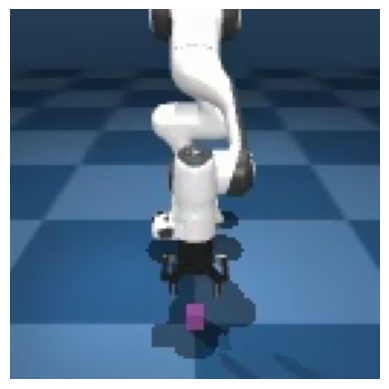

In [31]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset
import matplotlib.pyplot as plt

dataset = LeRobotDataset("Sandyhsy/il_gym_pickcube_debug6", video_backend="pyav")
print(dataset)

sample = dataset[0]
print(sample.keys())

camera_keys = [k for k in sample.keys() if "observation.images" in k or "pixels" in k]
print(camera_keys)

img = sample[camera_keys[0]].permute(1, 2, 0).numpy()

plt.imshow(img)
plt.axis("off")
plt.show()